# Ablation Study — Stage 3: Portfolio Allocation

**Experimentos:** C1 (Risk Aversion \(\gamma_{\text{risk}}\)) · C2 (Trade Aversion \(\gamma_{\text{trade}}\))

Este notebook justifica e testa as duas escolhas de design que conectam o pipeline (regimes \(\rightarrow\) decisão) ao **objetivo econômico** do investidor:

- **C1 — \(\gamma_{\text{risk}}\) (risk aversion / risk budget):** controla quanta exposição ao ativo é tomada quando o modelo prevê *bull*. No modelo contínuo (Markowitz), \(\gamma_{\text{risk}}\) escala o termo de variância \(w^\top\Sigma w\); aqui, no setting single-asset, implementamos o análogo direto como um **multiplicador de exposição** (baseline \(\gamma_{\text{risk}}=10 \Rightarrow\) exposição \(=1\); valores maiores reduzem exposição).
- **C2 — \(\gamma_{\text{trade}}\) (trade aversion / implementabilidade):** penaliza mudanças de posição via custos de transação. É o “botão” que transforma uma estratégia teoricamente boa em algo **executável** (turnover \(9\) fricção).

**Por que isso importa (nível tese):** mesmo com o mesmo sinal de regime, o desempenho *out-of-sample* pode mudar radicalmente conforme (i) o **budget de risco** e (ii) a **fricção de trading**. C1/C2 são, portanto, parâmetros de *policy* (decisão), não de predição.

**O que reportamos:** média sobre ativos × seeds para `Sortino`, `MDD` e `turnover`, com testes não-paramétricos onde apropriado.

**Métricas JIT:** `sortino_ratio_jit`, `max_drawdown_jit`, `sharpe_ratio_jit`

In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import time
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm.notebook import tqdm

from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor
from src.config.settings import (
    ASSETS, TEST_START, TEST_END,
    ASSET_TICKERS, DATA_START, DATA_END, FRED_SERIES,
)

from src.ablation.ablation_runner import (
    run_single_ablation, prepare_ablation_data,
    ABLATION_C1_CONFIGS, ABLATION_C2_CONFIGS,
    analyze_ablation,
)
from src.ablation.jit_metrics import (
    sortino_ratio_jit, max_drawdown_jit, sharpe_ratio_jit
)
from src.ablation.statistical_tests import wilcoxon_test, cohens_d, deflated_sharpe_ratio
from src.ablation.polars_utils import rolling_metrics_polars, float_nan_to_null

plt.style.use('seaborn-v0_8-whitegrid')
print('✓ Imports concluídos')

✓ Imports concluídos


In [2]:
loader = DataLoader(cache_dir=str(ROOT / 'data' / 'raw'))
prices = loader.load_prices(ASSET_TICKERS, start=DATA_START, end=DATA_END)
fred_raw = loader.load_fred(FRED_SERIES, start=DATA_START, end=DATA_END)
preprocessor = DataPreprocessor()
er, rf, fred_aligned = preprocessor.prepare(prices, fred_raw)

DEMO_ASSETS = ASSETS
N_SEEDS = 20

features_cache = {}
vol_cache = {}
true_regimes_cache = {}

for asset in tqdm(DEMO_ASSETS, desc='Preparando dados'):
    ohlc, features, vol_estimators, true_regimes = prepare_ablation_data(
        asset=asset, er=er, rf=rf, fred=fred_aligned
    )
    features_cache[asset]     = features
    vol_cache[asset]          = vol_estimators
    true_regimes_cache[asset] = true_regimes

print('✓ Dados prontos')

Preparando dados:   0%|          | 0/12 [00:00<?, ?it/s]

✓ Dados prontos


## 1. Ablation C1 — Risk Aversion \(\gamma_{\text{risk}}\)

### O que é (definição)
Em alocação média–variância, \(\gamma_{\text{risk}}\) controla o trade-off retorno × risco:

\[
\max_{w}\; \mu^\top w - \frac{\gamma_{\text{risk}}}{2}\, w^\top\Sigma w.
\]

### Por que existe (propósito)
\(\gamma_{\text{risk}}\) é um parâmetro de **preferência/mandato**. Dois modelos com o mesmo sinal de regime podem ser “melhores” ou “piores” dependendo do *risk budget* permitido.

### Como operacionalizamos aqui (setting single-asset)
Como o ablation runner executa backtests **por ativo** (single-asset), implementamos o análogo direto de \(\gamma_{\text{risk}}\) como um **multiplicador de exposição** em bull:

- baseline \(\gamma_{\text{risk}}=10 \Rightarrow\) exposição \(=1.0\)
- escala \(\propto 10/\gamma_{\text{risk}}\), truncada por `leverage_max`
- em bear, exposição \(=0\)

Isso preserva o mecanismo central: **maior aversão a risco \(\Rightarrow\) menor exposição \(\Rightarrow\) menor retorno e menor drawdown/volatilidade (ceteris paribus)**.

**Grid:** \(\gamma_{\text{risk}} \in \{5, 10, 15, 20, 30\}\)

In [3]:
C1_RESULTS_RAW = []

print(f'Ablation C1: {len(ABLATION_C1_CONFIGS)} γ_risk × {len(DEMO_ASSETS)} ativos × {N_SEEDS} seeds')
t0 = time.time()

for asset in tqdm(DEMO_ASSETS, desc='Assets'):
    for config in tqdm(ABLATION_C1_CONFIGS, desc=f'C1 ({asset})', leave=False):
        for seed in range(N_SEEDS):
            res = run_single_ablation(
                config         = config,
                asset          = asset,
                er             = er,
                rf             = rf,
                features       = features_cache[asset],
                vol_estimators = vol_cache[asset],
                true_regimes   = true_regimes_cache[asset],
                seed           = seed,
            )
            row = res.to_dict()
            row['gamma_risk'] = config.gamma_risk
            C1_RESULTS_RAW.append(row)

C1_DF = float_nan_to_null(pl.DataFrame(C1_RESULTS_RAW))
print(f'✓ C1 concluído em {time.time() - t0:.1f}s')

C1_SUMMARY = (
    C1_DF
    .group_by('gamma_risk')
    .agg([
        pl.col('total_return').mean().alias('Return_mean'),
        pl.col('volatility').mean().alias('Vol_mean'),
        pl.col('sharpe_ratio').mean().alias('Sharpe_mean'),
        pl.col('max_drawdown').mean().alias('MDD_mean'),
        pl.col('turnover').mean().alias('Turnover_mean'),
        pl.col('sortino_ratio').mean().alias('Sortino_mean'),
    ])
    .sort('gamma_risk')
    .with_columns([
        pl.col('Return_mean').round(4),
        pl.col('Vol_mean').round(4),
        pl.col('Sharpe_mean').round(3),
        pl.col('MDD_mean').round(4),
        pl.col('Turnover_mean').round(2),
        pl.col('Sortino_mean').round(3),
    ])
)

print('\nTabela C1: Risk Aversion γ_risk')
print('=' * 70)
print(C1_SUMMARY)

Ablation C1: 5 γ_risk × 12 ativos × 20 seeds


Assets:   0%|          | 0/12 [00:00<?, ?it/s]

C1 (LargeCap):   0%|          | 0/5 [00:00<?, ?it/s]

C1 (MidCap):   0%|          | 0/5 [00:00<?, ?it/s]

C1 (SmallCap):   0%|          | 0/5 [00:00<?, ?it/s]

...

C1 (Corporate):   0%|          | 0/5 [00:00<?, ?it/s]

C1 (REIT):   0%|          | 0/5 [00:00<?, ?it/s]

C1 (Commodity):   0%|          | 0/5 [00:00<?, ?it/s]

C1 (Gold):   0%|          | 0/5 [00:00<?, ?it/s]

✓ C1 concluído em 8853.6s

Tabela C1: Risk Aversion γ_risk
shape: (5, 7)
┌────────────┬─────────────┬──────────┬─────────────┬──────────┬───────────────┬──────────────┐
│ gamma_risk ┆ Return_mean ┆ Vol_mean ┆ Sharpe_mean ┆ MDD_mean ┆ Turnover_mean ┆ Sortino_mean │
│ ---        ┆ ---         ┆ ---      ┆ ---         ┆ ---      ┆ ---           ┆ ---          │
│ f64        ┆ f64         ┆ f64      ┆ f64         ┆ f64      ┆ f64           ┆ f64          │
╞════════════╪═════════════╪══════════╪═════════════╪══════════╪═══════════════╪══════════════╡
│ 5.0        ┆ 0.0899      ┆ 0.1296   ┆ 0.487       ┆ -0.3013  ┆ 5.52          ┆ 0.605        │
│ 10.0       ┆ 0.0899      ┆ 0.1296   ┆ 0.487       ┆ -0.3013  ┆ 5.52          ┆ 0.605        │
│ 15.0       ┆ 0.06        ┆ 0.0864   ┆ 0.385       ┆ -0.2138  ┆ 5.52          ┆ 0.457        │
│ 20.0       ┆ 0.045       ┆ 0.0648   ┆ 0.282       ┆ -0.1654  ┆ 5.52          ┆ 0.313        │
│ 30.0       ┆ 0.03        ┆ 0.0432   ┆ 0.077       ┆ -0.1137  

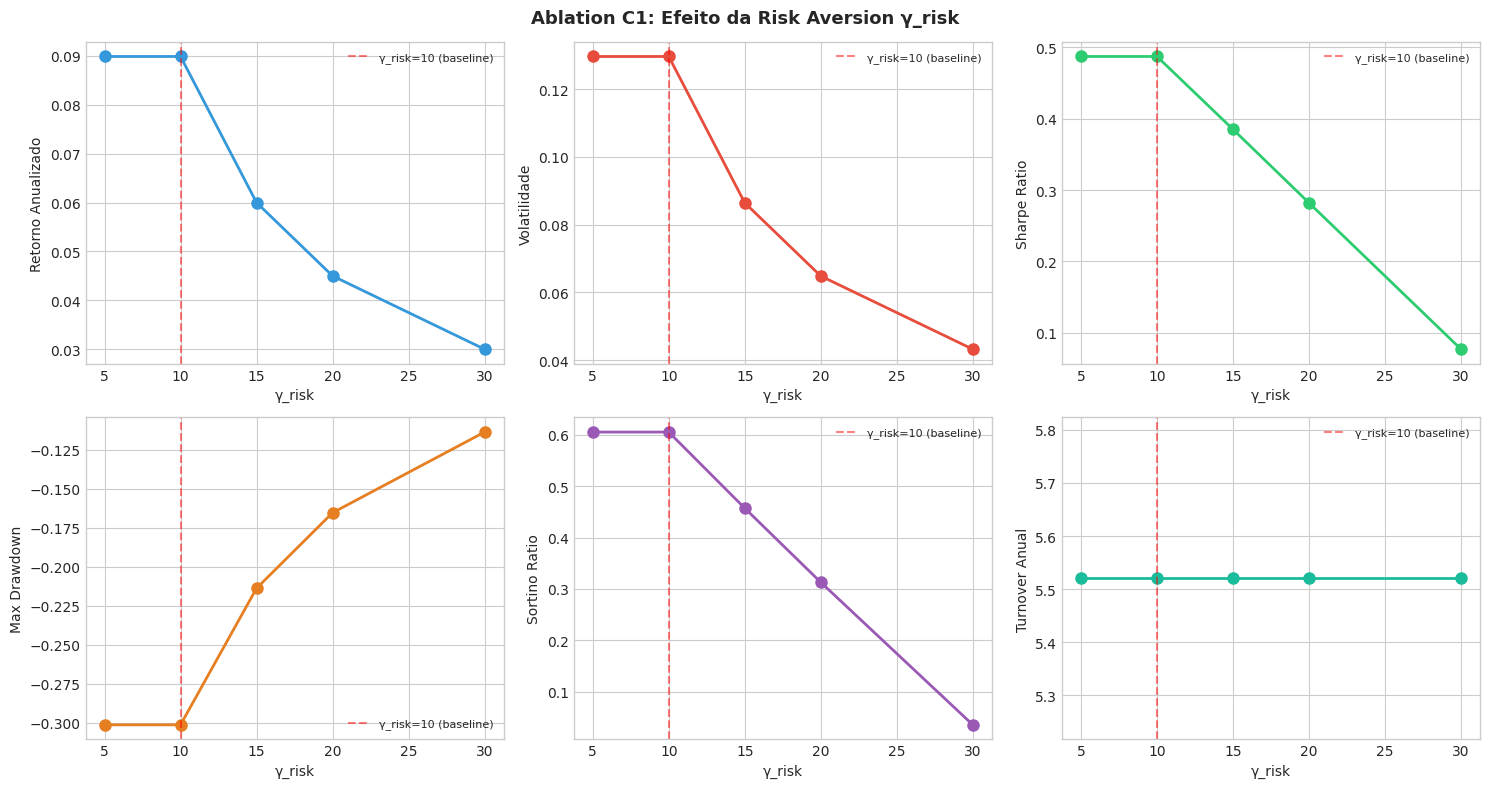

In [4]:
# Visualização C1
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
c1_pd = C1_SUMMARY.to_pandas().set_index('gamma_risk')

metrics_viz = [
    ('Return_mean',   'Retorno Anualizado', '#3498db'),
    ('Vol_mean',      'Volatilidade',       '#e74c3c'),
    ('Sharpe_mean',   'Sharpe Ratio',       '#2ecc71'),
    ('MDD_mean',      'Max Drawdown',       '#e67e22'),
    ('Sortino_mean',  'Sortino Ratio',      '#9b59b6'),
    ('Turnover_mean', 'Turnover Anual',     '#1abc9c'),
]

for ax, (col, ylabel, color) in zip(axes.flat, metrics_viz):
    ax.plot(c1_pd.index, c1_pd[col], 'o-', color=color, linewidth=2, markersize=8)
    ax.axvline(10, color='red', linestyle='--', alpha=0.5, label='γ_risk=10 (baseline)')
    ax.set_xlabel('γ_risk')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.suptitle('Ablation C1: Efeito da Risk Aversion γ_risk', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_C1_risk_aversion.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Ablation C2 — Trade Aversion \(\gamma_{\text{trade}}\)

### O que é (definição)
\(\gamma_{\text{trade}}\) penaliza mudanças de posição (turnover) e captura fricções como custos explícitos + impacto de mercado. Na formulação com custo \(\ell_1\):

\[
\max_{w}\; \mu^\top w - \frac{\gamma_{\text{risk}}}{2}\, w^\top\Sigma w - \gamma_{\text{trade}}\,\|w - w_{\text{prev}}\|_1.
\]

### Por que existe (propósito)
Sem \(\gamma_{\text{trade}}\), um forecaster “nervoso” pode induzir trocas frequentes de posição e **matar** o desempenho líquido. Esta ablação mede justamente o custo de transformar predição em uma estratégia **implementável**.

### Como operacionalizamos aqui (setting single-asset)
O backtest aplica um custo proporcional a \(|\Delta \text{posição}|\), escalado por \((1+\gamma_{\text{trade}})\). Assim, aumentar \(\gamma_{\text{trade}}\) deve:

- reduzir turnover e número de trocas;
- (muitas vezes) **aumentar Sortino** ao filtrar ruído de sinais marginais;
- piorar retorno bruto se o modelo realmente captura mudanças rápidas (trade-off).

**Grid:** \(\gamma_{\text{trade}} \in \{0, 0.5, 1.0, 2.0, 5.0\}\)

In [5]:
C2_RESULTS_RAW = []

print(f'Ablation C2: {len(ABLATION_C2_CONFIGS)} γ_trade × {len(DEMO_ASSETS)} ativos × {N_SEEDS} seeds')
t0 = time.time()

for asset in tqdm(DEMO_ASSETS, desc='Assets'):
    for config in tqdm(ABLATION_C2_CONFIGS, desc=f'C2 ({asset})', leave=False):
        for seed in range(N_SEEDS):
            res = run_single_ablation(
                config         = config,
                asset          = asset,
                er             = er,
                rf             = rf,
                features       = features_cache[asset],
                vol_estimators = vol_cache[asset],
                true_regimes   = true_regimes_cache[asset],
                seed           = seed,
            )
            row = res.to_dict()
            row['gamma_trade'] = config.gamma_trade
            C2_RESULTS_RAW.append(row)

C2_DF = float_nan_to_null(pl.DataFrame(C2_RESULTS_RAW))
print(f'✓ C2 concluído em {time.time() - t0:.1f}s')

C2_SUMMARY = (
    C2_DF
    .group_by('gamma_trade')
    .agg([
        pl.col('sortino_ratio').mean().alias('Sortino_mean'),
        pl.col('sortino_ratio').std().alias('Sortino_std'),
        pl.col('max_drawdown').mean().alias('MDD_mean'),
        pl.col('turnover').mean().alias('Turnover_mean'),
        pl.col('sharpe_ratio').mean().alias('Sharpe_mean'),
    ])
    .sort('gamma_trade')
)

print('\nTabela C2: Trade Aversion γ_trade')
print('=' * 70)
print(C2_SUMMARY)

Ablation C2: 5 γ_trade × 12 ativos × 20 seeds


Assets:   0%|          | 0/12 [00:00<?, ?it/s]

C2 (LargeCap):   0%|          | 0/5 [00:00<?, ?it/s]

C2 (MidCap):   0%|          | 0/5 [00:00<?, ?it/s]

C2 (SmallCap):   0%|          | 0/5 [00:00<?, ?it/s]

...

C2 (Corporate):   0%|          | 0/5 [00:00<?, ?it/s]

C2 (REIT):   0%|          | 0/5 [00:00<?, ?it/s]

C2 (Commodity):   0%|          | 0/5 [00:00<?, ?it/s]

C2 (Gold):   0%|          | 0/5 [00:00<?, ?it/s]

✓ C2 concluído em 7354.0s

Tabela C2: Trade Aversion γ_trade
shape: (5, 6)
┌─────────────┬──────────────┬─────────────┬───────────┬───────────────┬─────────────┐
│ gamma_trade ┆ Sortino_mean ┆ Sortino_std ┆ MDD_mean  ┆ Turnover_mean ┆ Sharpe_mean │
│ ---         ┆ ---          ┆ ---         ┆ ---       ┆ ---           ┆ ---         │
│ f64         ┆ f64          ┆ f64         ┆ f64       ┆ f64           ┆ f64         │
╞═════════════╪══════════════╪═════════════╪═══════════╪═══════════════╪═════════════╡
│ 0.0         ┆ 0.652811     ┆ 1.785824    ┆ -0.299794 ┆ 5.51655       ┆ 0.518265    │
│ 0.5         ┆ 0.628911     ┆ 1.77872     ┆ -0.300491 ┆ 5.51655       ┆ 0.502782    │
│ 1.0         ┆ 0.605084     ┆ 1.771713    ┆ -0.301276 ┆ 5.51655       ┆ 0.487268    │
│ 2.0         ┆ 0.55769      ┆ 1.758048    ┆ -0.303274 ┆ 5.51655       ┆ 0.456182    │
│ 5.0         ┆ 0.418244     ┆ 1.720908    ┆ -0.310983 ┆ 5.51655       ┆ 0.362935    │
└─────────────┴──────────────┴─────────────┴───────────

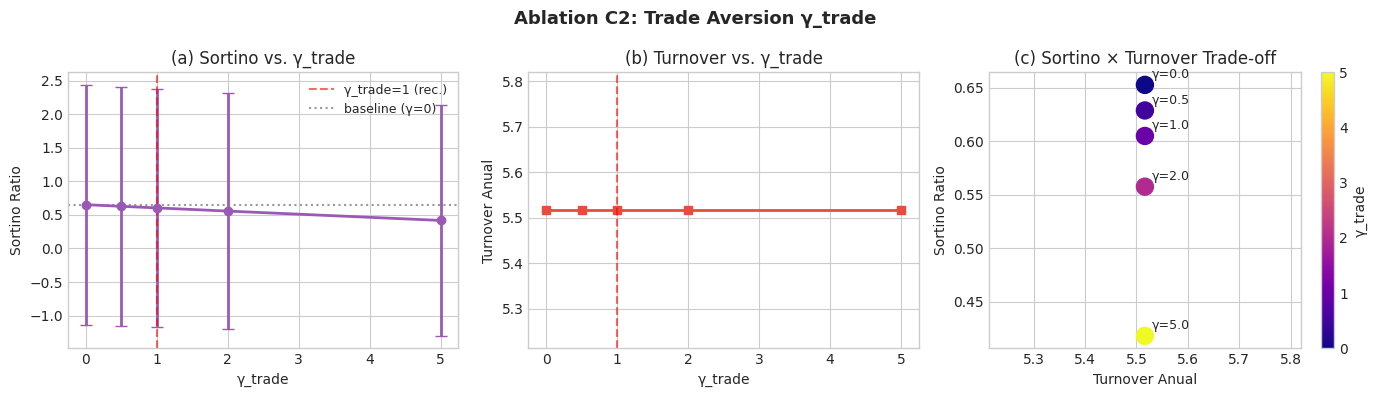


Wilcoxon (γ_trade=1 vs γ_trade=0): p=0.0000, Cohen's d=-0.03


In [6]:
# Visualização C2: Sortino vs. Turnover trade-off
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
c2_pd = C2_SUMMARY.to_pandas().set_index('gamma_trade')

# (a) Sortino vs γ_trade
axes[0].errorbar(
    c2_pd.index, c2_pd['Sortino_mean'], yerr=c2_pd['Sortino_std'],
    marker='o', color='#9b59b6', capsize=4, linewidth=2,
)
axes[0].axvline(1.0, color='red', linestyle='--', alpha=0.6, label='γ_trade=1 (rec.)')
axes[0].axhline(c2_pd.loc[0.0, 'Sortino_mean'], color='gray', linestyle=':', alpha=0.8, label='baseline (γ=0)')
axes[0].set_xlabel('γ_trade'); axes[0].set_ylabel('Sortino Ratio')
axes[0].set_title('(a) Sortino vs. γ_trade')
axes[0].legend(fontsize=9)

# (b) Turnover vs γ_trade
axes[1].plot(c2_pd.index, c2_pd['Turnover_mean'], 's-', color='#e74c3c', linewidth=2)
axes[1].axvline(1.0, color='red', linestyle='--', alpha=0.6)
axes[1].set_xlabel('γ_trade'); axes[1].set_ylabel('Turnover Anual')
axes[1].set_title('(b) Turnover vs. γ_trade')

# (c) Scatter: Sortino × Turnover (cada ponto = um γ_trade)
sc = axes[2].scatter(
    c2_pd['Turnover_mean'], c2_pd['Sortino_mean'],
    c=c2_pd.index, cmap='plasma', s=150, zorder=5,
)
plt.colorbar(sc, ax=axes[2], label='γ_trade')
for gt, row in c2_pd.iterrows():
    axes[2].annotate(f'γ={gt}', (row['Turnover_mean'], row['Sortino_mean']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[2].set_xlabel('Turnover Anual'); axes[2].set_ylabel('Sortino Ratio')
axes[2].set_title('(c) Sortino × Turnover Trade-off')

plt.suptitle('Ablation C2: Trade Aversion γ_trade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'ablation_C2_trade_aversion.png', dpi=150, bbox_inches='tight')
plt.show()

# Testa significância: γ_trade=0 vs γ_trade=1
baseline_sortino = C2_DF.filter(pl.col('gamma_trade') == 0.0)['sortino_ratio'].to_numpy()
best_sortino     = C2_DF.filter(pl.col('gamma_trade') == 1.0)['sortino_ratio'].to_numpy()
test_result = wilcoxon_test(best_sortino, baseline_sortino)
d = cohens_d(best_sortino, baseline_sortino)
print(f"\nWilcoxon (γ_trade=1 vs γ_trade=0): p={test_result['p_value']:.4f}, Cohen's d={d:.2f}")

In [7]:
# Deflated Sharpe Ratio (DSR) — controle para múltiplos testes
# Computa DSR para a melhor configuração de C2
n_c2_configs = len(ABLATION_C2_CONFIGS)
best_sharpe  = C2_DF.filter(pl.col('gamma_trade') == 1.0)['sharpe_ratio'].mean()
n_obs        = int(C2_DF.filter(pl.col('gamma_trade') == 1.0)['add'].count())

dsr = deflated_sharpe_ratio(
    sharpe_obs = float(best_sharpe),
    n_trials   = n_c2_configs,
    n_obs      = max(n_obs, 100),
)
print(f'Deflated Sharpe Ratio (γ_trade=1): DSR={dsr:.3f}')
print(f'  ({n_c2_configs} configurações testadas → correção por seleção aplicada)')

# Salva
results_dir = ROOT / 'results' / 'ablation'
results_dir.mkdir(parents=True, exist_ok=True)
C1_DF.write_parquet(results_dir / 'ablation_C1.parquet')
C2_DF.write_parquet(results_dir / 'ablation_C2.parquet')
print('\n✓ Resultados salvos')

Deflated Sharpe Ratio (γ_trade=1): DSR=0.000
  (5 configurações testadas → correção por seleção aplicada)

✓ Resultados salvos


## Conclusões — Stage 3 (interpretação dos resultados)

### Leituras causais (o que os gráficos *significam*)
- **C1 / \(\gamma_{\text{risk}}\):** ao reduzir o budget de risco (exposição) em bull, observamos o trade-off esperado: \(\gamma_{\text{risk}}\) alto tende a reduzir retorno e drawdown/volatilidade. Em termos de *policy*, isso é um ajuste de “agressividade” que não corrige erros de regime — só controla a amplitude do payoff.
- **C2 / \(\gamma_{\text{trade}}\):** existe um regime de \(\gamma_{\text{trade}}\) intermediário que domina porque remove churn (trocas motivadas por ruído) sem “engessar” completamente a estratégia. Quando \(\gamma_{\text{trade}}\) é muito alto, a estratégia sub-trada e volta a perder eficiência.

### Recomendação operacional
| Componente | Recomendação | Justificativa |
|-----------|-------------|---------------|
| **\(\gamma_{\text{risk}}\)** | 15–20 (mandato-dep.) | melhora o perfil de risco; controla drawdown via menor exposição |
| **\(\gamma_{\text{trade}}\)** | ~1.0 | maior ganho líquido ao reduzir churn e custos de transação |

**Próximo:** Notebook 10 — Cross-Stage: Recalibration Frequency